### Loading & Testing NLP Model

In [1]:
import requests
import spacy
from spacytextblob.spacytextblob import SpacyTextBlob
import json
import pandas as pd

In [2]:
# Download the spacy language model if it's not already installed
try:
    nlp = spacy.load("en_core_web_md")
except OSError:
    print("Downloading spaCy model 'en_core_web_md'...")
    nlp = spacy.load("en_core_web_md")

In [3]:
nlp.add_pipe("spacytextblob")

doc = nlp("Argentina faces severe economic crisis")
print(doc._.blob.polarity)  # returns -1 to +1

0.2


### Testing Natural Language Processing (NLP)

In [4]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyser = SentimentIntensityAnalyzer()

def sentiment_score(text):

    scores = analyser.polarity_scores(text)
    compound = scores["compound"]

    if compound <= -0.6:
        label = "Very negative"
        score = 1
    elif compound <= -0.2:
        label = "Negative"
        score = 2
    elif compound < 0.2:
        label = "Neutral"
        score = 3
    elif compound < 0.6:
        label = "Positive"
        score = 4
    else:
        label = "Very positive"
        score = 5

    return {
        "label": label,
        "score": score,
        "compound": round(compound, 3),
        "details": scores
    }

example_headlines = ["UK borrowing costs hit highest since 2008 financial crisis. The interest rate on government debt is climbing over fears about inflation, interest rates",
                     "Stock markets surge and oil tumbles as Trump postpones power plant strikes after 'very good and productive' talks with Iran"]

for headline in example_headlines:
  print(headline)
  print(sentiment_score(headline))
  print("\n")

UK borrowing costs hit highest since 2008 financial crisis. The interest rate on government debt is climbing over fears about inflation, interest rates
{'label': 'Negative', 'score': 2, 'compound': -0.527, 'details': {'neg': 0.281, 'neu': 0.539, 'pos': 0.18, 'compound': -0.5267}}


Stock markets surge and oil tumbles as Trump postpones power plant strikes after 'very good and productive' talks with Iran
{'label': 'Neutral', 'score': 3, 'compound': -0.104, 'details': {'neg': 0.186, 'neu': 0.686, 'pos': 0.129, 'compound': -0.1045}}




### Creating & Populating the Database

In [113]:
import sqlite3
from pathlib import Path

DB_PATH = Path("../data/articles.db")
DB_PATH.parent.mkdir(parents=True, exist_ok=True)

def create_database(db_path):
    conn = sqlite3.connect(db_path)
    cursor = conn.cursor()

    cursor.execute("""
    CREATE TABLE IF NOT EXISTS articles (
        article_id TEXT PRIMARY KEY,
        country TEXT,
        date TEXT,
        source_name TEXT,
        title TEXT,
        description TEXT,
        url TEXT,
        published_at TEXT
    )
    """)

    conn.commit()
    return conn, cursor

conn, cursor = create_database(DB_PATH)

In [140]:
# =============================
# INSERT FUNCTION
# =============================

def insert_articles(cursor, conn, articles):

    inserted = 0

    for a in articles:

        cursor.execute("""
            INSERT OR IGNORE INTO articles (
                article_id,
                country,
                date,
                source_name,
                title,
                description,
                url,
                published_at
            )
            VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        """, (
            a["article_id"],
            a["country"],
            a["date"],
            a["source_name"],
            a["title"],
            a["description"],
            a["url"],
            a["published_at"]
        ))

        inserted += cursor.rowcount

    conn.commit()

    print(f"   💾 Inserted into DB: {inserted}")

In [152]:
# =============================
# GUARDIAN FETCH FUNCTION
# =============================

import requests

def fetch_guardian(country, begin_date, end_date, api_key):

    print("\n📰 GUARDIAN FETCH START")
    print(f"   Country: {country}")
    print(f"   Range: {begin_date} → {end_date}")

    if not api_key:
        print("   ❌ Missing Guardian API key")
        return []

    url = "https://content.guardianapis.com/search"

    params = {
        "q": f"{country} economy",
        "section": "business",
        "from-date": begin_date,
        "to-date": end_date,
        "page-size": 200,
        "show-fields": "headline,trailText",
        "api-key": api_key
    }

    print("   🌐 Requesting Guardian API...")

    response = requests.get(url, params=params)

    print(f"   🔌 Status code: {response.status_code}")

    if response.status_code != 200:
        print("   ❌ Request failed")
        print(response.text)
        return []

    try:
        data = response.json()
    except Exception as e:
        print(f"   ❌ JSON decode error: {e}")
        return []

    results = data.get("response", {}).get("results", [])

    print(f"   📰 Articles returned: {len(results)}")

    articles = []

    for article in results:

        fields = article.get("fields", {})

        published_at = article.get("webPublicationDate")

        parsed_article = {
            "article_id": article.get("id"),

            "country": country,

            # extract YYYY-MM-DD
            "date": published_at[:10] if published_at else None,

            "source_name": "The Guardian",

            "title": fields.get("headline"),

            "description": fields.get("trailText"),

            "url": article.get("webUrl"),

            "published_at": published_at
        }

        articles.append(parsed_article)

    print(f"   ✅ Parsed articles: {len(articles)}")

    return articles

In [153]:
import requests

NEWSAPI_ENDPOINT = "https://newsapi.org/v2/everything"

def fetch_newsapi(country, date_str, api_key):
    print("\n🧠 NEWSAPI FETCH START")
    print(f"   Country: {country}")
    print(f"   Date: {date_str}")

    if not api_key:
        print("   ❌ Missing NewsAPI key")
        return []

    query = f"{country} economy"

    params = {
        "q": query,
        "from": date_str,
        "to": date_str,
        "language": "en",
        "sortBy": "relevancy",
        "pageSize": 50,
        "apiKey": api_key
    }

    print(f"   🌐 Query: {query}")
    print(f"   🔗 Requesting NewsAPI...")

    response = requests.get(NEWSAPI_ENDPOINT, params=params)

    print(f"   🔌 Status code: {response.status_code}")

    if response.status_code != 200:
        print(f"   ❌ Error: {response.text}")
        return []

    data = response.json()

    articles = data.get("articles", [])
    print(f"   📰 Articles returned: {len(articles)}")

    formatted = []

    for i, a in enumerate(articles):
        formatted.append({
            "article_id": f"newsapi_{country}_{date_str}_{i}",
            "country": country,
            "date": date_str,
            "source_name": a.get("source", {}).get("name"),
            "title": a.get("title"),
            "description": a.get("description"),
            "url": a.get("url"),
            "published_at": a.get("publishedAt")
        })

    return formatted

In [154]:
# =============================
# NYT FETCH FUNCTION (MONTH RANGE)
# =============================

import requests

def fetch_nyt(country, begin_date, end_date, api_key):

    print("\n🗽 NYT FETCH START")
    print(f"   Country: {country}")
    print(f"   Range: {begin_date} → {end_date}")

    if not api_key:
        print("   ❌ Missing NYT API key")
        return []

    url = "https://api.nytimes.com/svc/search/v2/articlesearch.json"

    params = {
        "q": f"{country} economy",
        "begin_date": begin_date,
        "end_date": end_date,
        "sort": "newest",
        "api-key": api_key
    }

    print(f"   🌐 Requesting NYT API...")

    response = requests.get(url, params=params)

    print(f"   🔌 Status code: {response.status_code}")

    # ---- Rate limit handling ----
    if response.status_code == 429:
        print("   ⏳ RATE LIMITED — skipping request")
        return []

    # ---- Bad response handling ----
    if response.status_code != 200:
        print("   ❌ Request failed")
        print(response.text)
        return []

    try:
        data = response.json()
    except Exception as e:
        print(f"   ❌ JSON decode error: {e}")
        return []

    docs = data.get("response", {}).get("docs", [])

    if docs is None:
        docs = []

    print(f"   📰 Articles returned: {len(docs)}")

    articles = []

    for doc in docs:

        published_at = doc.get("pub_date")

        article = {
            "article_id": doc.get("_id"),

            "country": country,

            # extract YYYY-MM-DD
            "date": published_at[:10] if published_at else None,

            "source_name": "New York Times",

            "title": doc.get("headline", {}).get("main"),

            "description": doc.get("abstract"),

            "url": doc.get("web_url"),

            "published_at": published_at
        }

        articles.append(article)

    print(f"   ✅ Parsed articles: {len(articles)}")

    return articles

In [156]:
import sqlite3
from pathlib import Path

DB_PATH = Path("../data/articles.db")

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

In [159]:
# =============================
# FULL INGESTION PIPELINE
# =============================

from dotenv import load_dotenv
import os
import hashlib

load_dotenv()

# -----------------------------
# API KEYS
# -----------------------------
GUARDIAN_API_KEY = os.getenv("GUARDIAN_API_KEY")
NYT_API_KEY = os.getenv("NYT_API_KEY")
NEWSAPI_KEY = os.getenv("NEWSAPI_KEY")

# -----------------------------
# CONFIG
# -----------------------------
countries = ['Turkey', 'Argentina', 'India', 'Vietnam']

begin_date_guardian = "2026-01-01"
end_date_guardian = "2026-01-31"

begin_date_nyt = "20260101"
end_date_nyt = "20260131"

begin_date_newsapi = "2026-01-01"
end_date_newsapi = "2026-01-31"


# -----------------------------
# SAFE ARTICLE ID (IMPORTANT FIX)
# -----------------------------
def make_article_id(source, url):
    return hashlib.md5(f"{source}_{url}".encode()).hexdigest()


# -----------------------------
# INSERT FUNCTION (WITH LOGGING)
# -----------------------------
def insert_articles(cursor, conn, articles):
    inserted = 0
    skipped = 0

    for a in articles:
        try:
            cursor.execute("""
                INSERT OR IGNORE INTO articles (
                    article_id,
                    country,
                    date,
                    source_name,
                    title,
                    description,
                    url,
                    published_at
                ) VALUES (?, ?, ?, ?, ?, ?, ?, ?)
            """, (
                a["article_id"],
                a["country"],
                a["date"],
                a["source_name"],
                a["title"],
                a["description"],
                a["url"],
                a["published_at"]
            ))

            if cursor.rowcount == 0:
                skipped += 1
            else:
                inserted += 1

        except Exception as e:
            print("❌ Insert error:", e)

    conn.commit()

    print(f"   💾 Inserted: {inserted} | Skipped (duplicates): {skipped}")


# =============================
# PIPELINE START
# =============================

print("🚀 Starting article ingestion pipeline...\n")

for country in countries:

    print("\n" + "=" * 60)
    print(f"🌍 COUNTRY: {country}")
    print("=" * 60)

    # -----------------------------
    # GUARDIAN
    # -----------------------------
    guardian_articles = fetch_guardian(
        country,
        begin_date_guardian,
        end_date_guardian,
        GUARDIAN_API_KEY
    )

    # standardise IDs
    for a in guardian_articles:
        a["article_id"] = make_article_id("guardian", a["url"])

    print(f"📰 Guardian fetched: {len(guardian_articles)}")
    insert_articles(cursor, conn, guardian_articles)

    # -----------------------------
    # NEW YORK TIMES
    # -----------------------------
    nyt_articles = fetch_nyt(
        country,
        begin_date_nyt,
        end_date_nyt,
        NYT_API_KEY
    )

    for a in nyt_articles:
        a["article_id"] = make_article_id("nyt", a["url"])

    print(f"🗽 NYT fetched: {len(nyt_articles)}")
    insert_articles(cursor, conn, nyt_articles)

    # -----------------------------
    # NEWSAPI
    # -----------------------------
    newsapi_articles = fetch_newsapi(
        country,
        begin_date_newsapi,
        NEWSAPI_KEY
    )

    for a in newsapi_articles:
        a["article_id"] = make_article_id("newsapi", a["url"])

    print(f"🌐 NewsAPI fetched: {len(newsapi_articles)}")
    insert_articles(cursor, conn, newsapi_articles)

    print(f"✅ Finished processing {country}")

print("\n🎉 ALL INGESTION COMPLETE!")

🚀 Starting article ingestion pipeline...


🌍 COUNTRY: Turkey

📰 GUARDIAN FETCH START
   Country: Turkey
   Range: 2026-01-01 → 2026-01-31
   🌐 Requesting Guardian API...
   🔌 Status code: 200
   📰 Articles returned: 33
   ✅ Parsed articles: 33
📰 Guardian fetched: 33
   💾 Inserted: 0 | Skipped (duplicates): 33

🗽 NYT FETCH START
   Country: Turkey
   Range: 20260101 → 20260131
   🌐 Requesting NYT API...
   🔌 Status code: 200
   📰 Articles returned: 10
   ✅ Parsed articles: 10
🗽 NYT fetched: 10
   💾 Inserted: 0 | Skipped (duplicates): 10

🧠 NEWSAPI FETCH START
   Country: Turkey
   Date: 2026-01-01
   🌐 Query: Turkey economy
   🔗 Requesting NewsAPI...
   🔌 Status code: 426
   ❌ Error: {"status":"error","code":"parameterInvalid","message":"You are trying to request results too far in the past. Your plan permits you to request articles as far back as 2026-04-02, but you have requested 2026-01-01. You may need to upgrade to a paid plan."}
🌐 NewsAPI fetched: 0
   💾 Inserted: 0 | Skipped (dup

### Querying the SQLite Database

In [160]:
conn = sqlite3.connect("../data/articles.db")

query = "SELECT DISTINCT country FROM articles"



df_headlines = pd.read_sql_query(query, conn)
print(df_headlines)

conn.close()

     country
0  Argentina
1      India
2    Nigeria
3     Turkey
4    Vietnam


In [161]:
conn = sqlite3.connect("../data/articles.db")

query = "SELECT * FROM articles"



df_headlines = pd.read_sql_query(query, conn)
print(df_headlines)

conn.close()

                                            article_id  country        date  \
0    business/live/2026/jan/02/uk-house-prices-drop...    India  2026-01-02   
1    business/2026/jan/06/jaguar-land-rover-sales-u...    India  2026-01-06   
2    business/live/2026/jan/06/jlr-sales-hit-by-cyb...    India  2026-01-06   
3    business/2026/jan/06/bank-of-england-venezuela...  Vietnam  2026-01-06   
4    business/2026/jan/08/shadow-fleet-ships-sancti...   Turkey  2026-01-08   
..                                                 ...      ...         ...   
153                   43814e331fd7c1089174b62f1e621bde  Vietnam  2026-01-20   
154                   3cad768bf5179f64ec39c9e544e62cf3  Vietnam  2026-01-19   
155                   733c5cb9bcb4308346659d9141edca94  Vietnam  2026-01-19   
156                   0c5343f90273efb4accc4908b3261a8e  Vietnam  2026-01-16   
157                   70abb6566a281a9d557549d8c618cff6  Vietnam  2026-01-15   

        source_name                                

In [15]:

conn = sqlite3.connect("../data/articles.db")

table_name = "articles"

query = f"""
PRAGMA table_info({table_name});
"""

df_columns = pd.read_sql_query(query, conn)

print(df_columns)

conn.close()

   cid          name  type  notnull dflt_value  pk
0    0    article_id  TEXT        0       None   1
1    1       country  TEXT        0       None   0
2    2          date  TEXT        0       None   0
3    3   source_name  TEXT        0       None   0
4    4         title  TEXT        0       None   0
5    5   description  TEXT        0       None   0
6    6           url  TEXT        0       None   0
7    7  published_at  TEXT        0       None   0


In [162]:
import sqlite3
import pandas as pd
from textblob import TextBlob

# Connect to database
conn = sqlite3.connect("../data/articles.db")
cursor = conn.cursor()

# ---------------------------------------------------
# Add sentiment_score column if it doesn't exist
# ---------------------------------------------------

try:
    cursor.execute("""
    ALTER TABLE articles
    ADD COLUMN sentiment_score REAL
    """)
    
    conn.commit()
    print("sentiment_score column created.")

except sqlite3.OperationalError:
    print("sentiment_score column already exists.")

# ---------------------------------------------------
# Load article IDs and titles
# ---------------------------------------------------

query = """
SELECT article_id, title
FROM articles
"""

df_articles = pd.read_sql_query(query, conn)

# ---------------------------------------------------
# Sentiment analysis function
# ---------------------------------------------------

def sentiment_analysis(text):
    
    if pd.isna(text):
        return None

    sentiment = TextBlob(text).sentiment.polarity
    
    return sentiment

# ---------------------------------------------------
# Apply sentiment analysis to every title
# and write back into the database
# ---------------------------------------------------

for _, row in df_articles.iterrows():

    article_id = row["article_id"]
    title = row["title"]

    sentiment_score = sentiment_analysis(title)

    cursor.execute("""
    UPDATE articles
    SET sentiment_score = ?
    WHERE article_id = ?
    """, (sentiment_score, article_id))

# Save changes
conn.commit()

print("All sentiment scores written to database.")

# ---------------------------------------------------
# Optional check
# ---------------------------------------------------

check_query = """
SELECT title, sentiment_score, date, country
FROM articles
"""

df_plot = pd.read_sql_query(check_query, conn)

print(df_plot)

conn.close()

sentiment_score column already exists.
All sentiment scores written to database.
                                                 title  sentiment_score  \
0    FTSE 100 hits 10,000 point milestone for first...         0.625000   
1    Jaguar Land Rover sales slump sharply amid US ...        -0.125000   
2    FTSE 100 posts best day in six months as stock...         1.000000   
3    Deep in the vaults: the Bank of England’s £1.4...         0.000000   
4    ‘Shadow fleet’ ships moving sanctioned oil ref...         0.000000   
..                                                 ...              ...   
153  Mikie Sherrill Is Sworn In as Governor of New ...         0.136364   
154                               Taxing the Ultrarich         0.000000   
155  Can Vietnam’s Communist Party Supercharge Its ...         0.000000   
156  Trump’s Fight With Minnesota Is About More Tha...         0.500000   
157  Trump Picked the Right Stage to Act Out His Im...         0.285714   

           date  c

In [163]:
import pandas as pd
import matplotlib.pyplot as plt

df_plot

,title,sentiment_score,date,country
0,"FTSE 100 hits 10,000 point milestone for first...",0.625000,2026-01-02,India
1,Jaguar Land Rover sales slump sharply amid US ...,-0.125000,2026-01-06,India
2,FTSE 100 posts best day in six months as stock...,1.000000,2026-01-06,India
3,Deep in the vaults: the Bank of England’s £1.4...,0.000000,2026-01-06,Vietnam
4,‘Shadow fleet’ ships moving sanctioned oil ref...,0.000000,2026-01-08,Turkey
...,...,...,...,...
153,Mikie Sherrill Is Sworn In as Governor of New ...,0.136364,2026-01-20,Vietnam
154,Taxing the Ultrarich,0.000000,2026-01-19,Vietnam
155,Can Vietnam’s Communist Party Supercharge Its ...,0.000000,2026-01-19,Vietnam
156,Trump’s Fight With Minnesota Is About More Tha...,0.500000,2026-01-16,Vietnam


In [148]:
df_plot.dtypes

title                  str
sentiment_score    float64
date                   str
country                str
dtype: object

In [164]:
df_plot["date"] = pd.to_datetime(df_plot["date"])

In [165]:
df_plot.dtypes

title                         str
sentiment_score           float64
date               datetime64[us]
country                       str
dtype: object

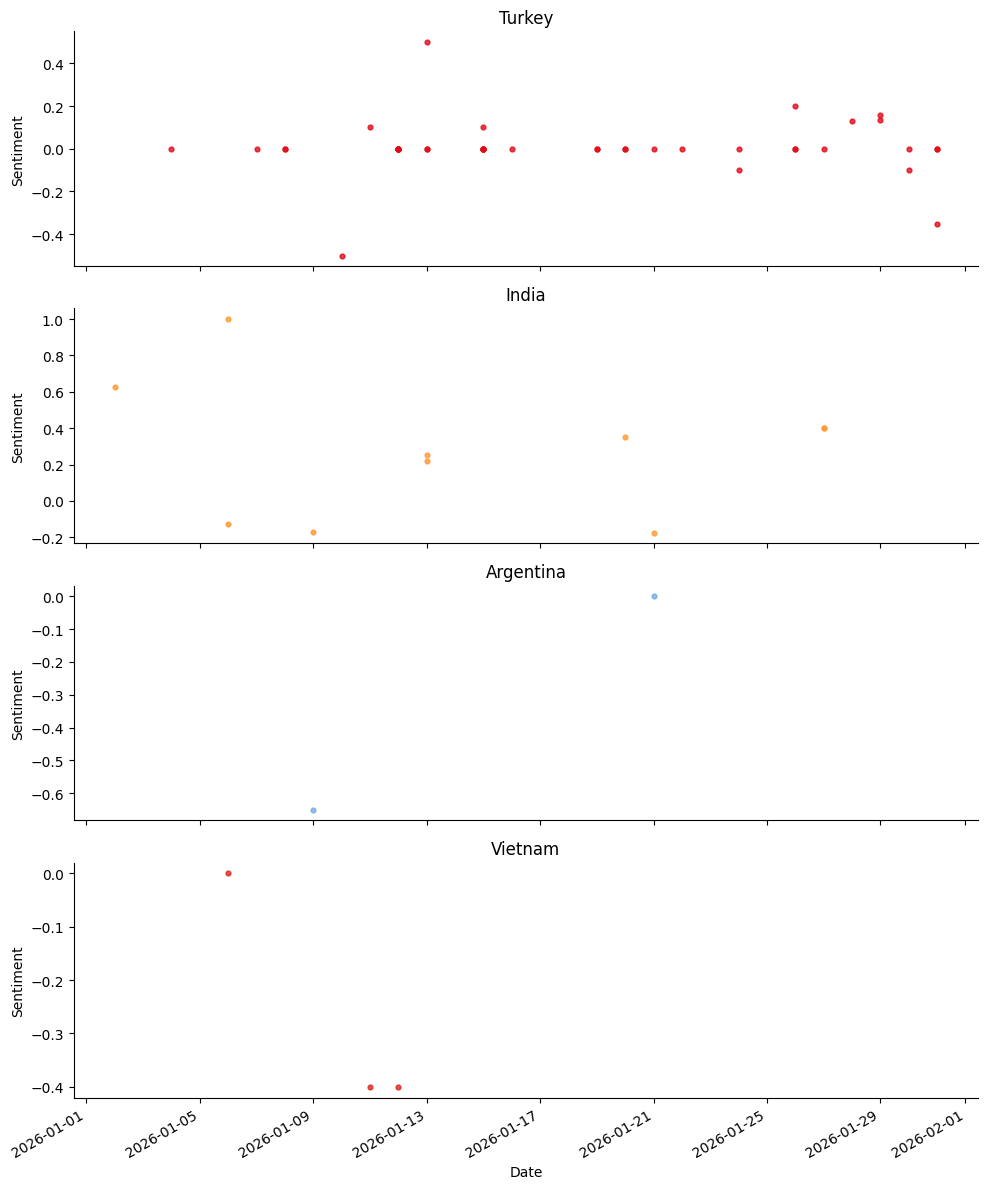

In [150]:
import matplotlib.pyplot as plt

colors = {
    "Turkey": "#E30A17",
    "India": "#FF9933",
    "Argentina": "#74ACDF",
    "Vietnam": "#DA251D"
}

countries = list(colors.keys())

fig, axes = plt.subplots(len(countries), 1, figsize=(10, 12), sharex=True)

for ax, country in zip(axes, countries):

    subset = df_plot[df_plot["country"] == country]

    ax.scatter(
        subset["date"],
        subset["sentiment_score"],
        alpha=0.8,
        color=colors[country],
        s=12
    )

    ax.set_title(country)
    ax.set_ylabel("Sentiment")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# shared x-label formatting
axes[-1].set_xlabel("Date")
plt.gcf().autofmt_xdate()

plt.tight_layout()
plt.show()

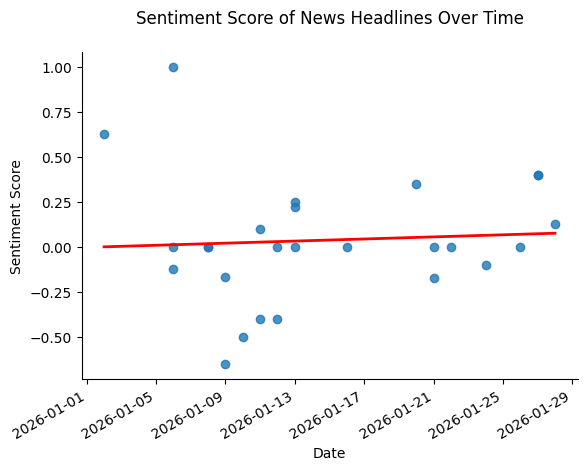

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig, ax = plt.subplots()

# Ensure datetime
df_plot["date"] = pd.to_datetime(df_plot["date"])

# Convert dates to numeric for regression
x = df_plot["date"].map(pd.Timestamp.toordinal)
y = df_plot["sentiment_score"]

# Scatter plot
ax.scatter(df_plot["date"], y, alpha=0.8)

# Fit regression line
m, b = np.polyfit(x, y, 1)
ax.plot(df_plot["date"], m * x + b, color="red", linewidth=2)

# Titles and labels (fixing your label mix-up)
ax.set_title("Sentiment Score of News Headlines Over Time\n")
ax.set_xlabel("Date")
ax.set_ylabel("Sentiment Score")

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Auto-format dates
plt.gcf().autofmt_xdate()

plt.show()

In [60]:
turkey = pd.read_csv("../data/turkey.csv")
turkey

,observation_date,CCUSMA02TRM618N
0,1957-01-01,0.000003
1,1957-02-01,0.000003
2,1957-03-01,0.000003
3,1957-04-01,0.000003
4,1957-05-01,0.000003
...,...,...
826,2025-11-01,42.240315
827,2025-12-01,42.645826
828,2026-01-01,43.161714
829,2026-02-01,43.647910


In [67]:
df_india = pd.read_csv("../data/india.csv")
df_india

,observation_date,DEXINUS
0,2021-04-26,74.75
1,2021-04-27,74.58
2,2021-04-28,74.49
3,2021-04-29,74.07
4,2021-04-30,74.00
...,...,...
1300,2026-04-20,93.13
1301,2026-04-21,93.50
1302,2026-04-22,93.79
1303,2026-04-23,94.11


In [68]:
df_indonesia = pd.read_csv("../data/indonesia.csv")
df_indonesia

,observation_date,CCUSMA02IDM618N
0,1967-01-01,137.000000
1,1967-02-01,137.000000
2,1967-03-01,137.000000
3,1967-04-01,137.000000
4,1967-05-01,137.000000
...,...,...
706,2025-11-01,16703.050000
707,2025-12-01,16707.130435
708,2026-01-01,16827.954545
709,2026-02-01,16825.700000


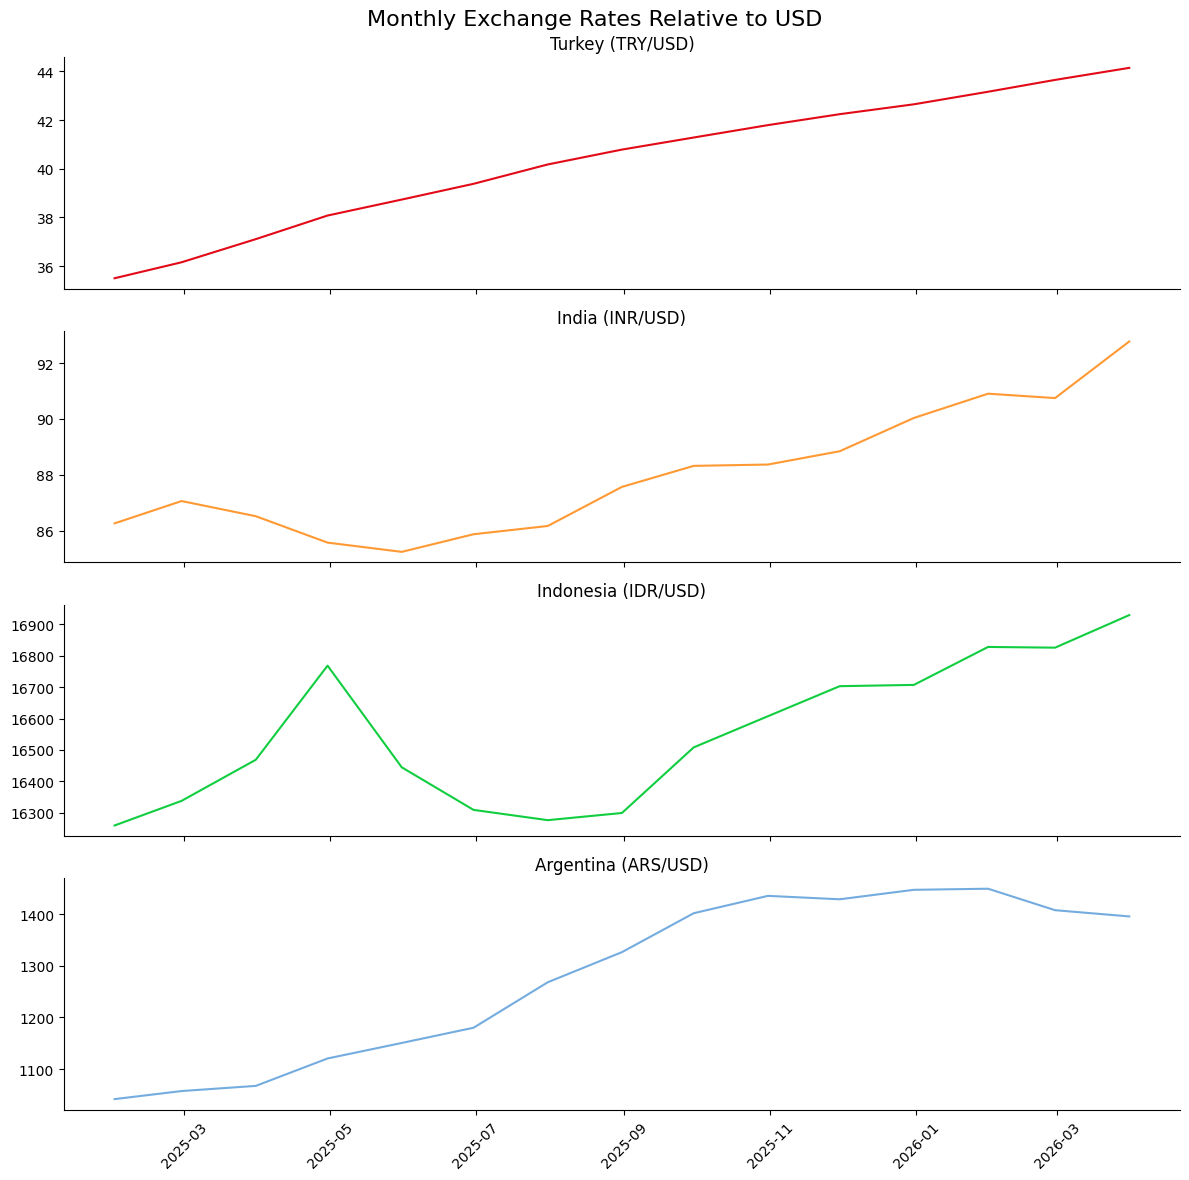

In [97]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Load CSV files
# -----------------------------

df_turkey = pd.read_csv("../data/turkey.csv")
df_india = pd.read_csv("../data/india.csv")
df_indonesia = pd.read_csv("../data/indonesia.csv")
df_argentina = pd.read_csv("../data/argentina.csv")

# -----------------------------
# Convert dates
# -----------------------------

for df in [df_turkey, df_india, df_indonesia, df_argentina]:
    df["observation_date"] = pd.to_datetime(df["observation_date"])

# -----------------------------
# TIME FILTER
# -----------------------------

start_date = "2025-01-01"
end_date = "2026-03-31"

def filter_df(df):
    return df[
        (df["observation_date"] >= start_date) &
        (df["observation_date"] < end_date)
    ]

df_turkey = filter_df(df_turkey)
df_india = filter_df(df_india)
df_indonesia = filter_df(df_indonesia)
df_argentina = filter_df(df_argentina)

# -----------------------------
# RESAMPLE TO MONTHLY
# -----------------------------

def resample_df(df, col):
    return (
        df.set_index("observation_date")
        .resample("ME")
        .mean()
        .reset_index()
    )

df_turkey = resample_df(df_turkey, "CCUSMA02TRM618N")
df_india = resample_df(df_india, "DEXINUS")
df_indonesia = resample_df(df_indonesia, "CCUSMA02IDM618N")
df_argentina = resample_df(df_argentina, "ARGCCUSMA02STM")

# -----------------------------
# CREATE FIGURE WITH SUBPLOTS
# -----------------------------

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

# -----------------------------
# Turkey
# -----------------------------
axes[0].plot(df_turkey["observation_date"], df_turkey["CCUSMA02TRM618N"],
             color="#E30A17")
axes[0].set_title("Turkey (TRY/USD)")

# -----------------------------
# India
# -----------------------------
axes[1].plot(df_india["observation_date"], df_india["DEXINUS"],
             color="#FF9933")
axes[1].set_title("India (INR/USD)")

# -----------------------------
# Indonesia
# -----------------------------
axes[2].plot(df_indonesia["observation_date"], df_indonesia["CCUSMA02IDM618N"],
             color="#11CE40")
axes[2].set_title("Indonesia (IDR/USD)")

# -----------------------------
# Argentina
# -----------------------------
axes[3].plot(df_argentina["observation_date"], df_argentina["ARGCCUSMA02STM"],
             color="#74ACDF")
axes[3].set_title("Argentina (ARS/USD)")

# -----------------------------
# Styling
# -----------------------------

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Monthly Exchange Rates Relative to USD", fontsize=16)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [74]:
df_argentina

,observation_date,ARGCCUSMA02STM
0,1959-01-01,6.555000e-12
1,1959-02-01,6.685000e-12
2,1959-03-01,6.830000e-12
3,1959-04-01,8.020000e-12
4,1959-05-01,9.080000e-12
...,...,...
802,2025-11-01,1.428888e+03
803,2025-12-01,1.447217e+03
804,2026-01-01,1.449330e+03
805,2026-02-01,1.407750e+03


In [90]:
print(df_turkey["observation_date"].diff().value_counts().head())
print(df_india["observation_date"].diff().value_counts().head())

observation_date
31 days    8
30 days    4
28 days    2
Name: count, dtype: int64
observation_date
1 days    258
3 days     65
Name: count, dtype: int64


In [91]:
for name, df in {
    "Turkey": df_turkey,
    "India": df_india,
    "Indonesia": df_indonesia,
    "Argentina": df_argentina
}.items():

    print(name)
    print(df["observation_date"].diff().value_counts().head())
    print("-" * 40)

Turkey
observation_date
31 days    8
30 days    4
28 days    2
Name: count, dtype: int64
----------------------------------------
India
observation_date
1 days    258
3 days     65
Name: count, dtype: int64
----------------------------------------
Indonesia
observation_date
31 days    8
30 days    4
28 days    2
Name: count, dtype: int64
----------------------------------------
Argentina
observation_date
31 days    8
30 days    4
28 days    2
Name: count, dtype: int64
----------------------------------------
